In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


# Decision Tree Classification Model - Sleep Health Dataset
# Wytrenowanie modelu klasyfikacyjnego do przewidywania zmiennej 'felt_rested'
# na podstawie zbioru sleep_health_dataset.csv


## WCZYTANIE I EKSPLORACJA DANYCH


In [3]:
file_path = "../resources/sleep_health_dataset.csv"
df = pd.read_csv(file_path)

if 'person_id' in df.columns:
    df = df.drop('person_id', axis=1)

print(f"\nRozmiar calego zbioru danych: {df.shape[0]} wierszy x {df.shape[1]} kolumn\n")

df.info()
df.describe().round(2)


Rozmiar calego zbioru danych: 100000 wierszy x 31 kolumn

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   gender                       100000 non-null  str    
 2   occupation                   100000 non-null  str    
 3   bmi                          100000 non-null  float64
 4   country                      100000 non-null  str    
 5   sleep_duration_hrs           100000 non-null  float64
 6   sleep_quality_score          100000 non-null  float64
 7   rem_percentage               100000 non-null  float64
 8   deep_sleep_percentage        100000 non-null  float64
 9   sleep_latency_mins           100000 non-null  int64  
 10  wake_episodes_per_night      100000 non-null  int64  
 11  caffeine_mg_before_bed       100000 non-null  int64  
 12  alcohol_uni

,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,34.71,26.29,6.42,4.87,20.24,20.25,19.84,3.35,38.85,0.60,...,14.94,5.73,7.13,66.57,0.56,0.08,20.54,1.20,59.23,0.39
std,11.04,4.48,1.27,1.51,3.41,4.25,7.58,1.92,69.40,1.06,...,21.39,1.62,3.48,7.23,0.50,0.28,2.90,0.79,22.25,0.49
min,18.00,16.00,3.00,1.00,10.00,5.00,1.00,0.00,0.00,0.00,...,0.00,1.00,0.00,45.00,0.00,0.00,15.00,-1.00,0.00,0.00
25%,26.00,23.20,5.53,3.80,18.00,17.40,14.00,2.00,0.00,0.00,...,0.00,4.80,4.70,62.00,0.00,0.00,18.50,0.67,44.20,0.00
50%,33.00,26.30,6.36,4.90,20.30,20.30,19.00,3.00,0.00,0.00,...,0.00,5.80,7.40,67.00,1.00,0.00,20.50,1.20,60.40,0.00
75%,42.00,29.30,7.27,6.00,22.60,23.20,25.00,5.00,80.00,1.00,...,30.00,6.80,9.70,71.00,1.00,0.00,22.50,1.74,75.80,1.00
max,69.00,45.00,10.50,10.00,30.00,30.00,58.00,8.00,400.00,6.00,...,116.00,10.00,18.00,99.00,1.00,1.00,28.00,3.00,100.00,1.00


## PREPROCESSING DANYCH


In [4]:
target_col = 'felt_rested'
y = df[target_col]
X = df.drop(columns=[target_col])

print(f"\nZmienne niezalezne (cechy): {X.columns.tolist()}")
print(f"\nZmienna zalezna (target): {target_col}")
print(f"Klasy: {sorted(y.unique())}")
print(f"\nRozklad klas:")
print(y.value_counts())


Zmienne niezalezne (cechy): ['age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk']

Zmienna zalezna (target): felt_rested
Klasy: [np.int64(0), np.int64(1)]

Rozklad klas:
felt_rested
0    60988
1    39012
Name: count, dtype: int64


In [5]:
categorical_cols = X.select_dtypes(include=['str']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\nZmienne kategoryczne: {categorical_cols}")
print(f"Zmienne numeryczne: {numerical_cols}")


label_encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"\nKodowanie {col}:")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name} -> {i}")

# Kodowanie zmiennej celu jesli jest kategoryczna
if y.dtype == 'str':
    le_target = LabelEncoder()
    y_encoded = le_target.fit_transform(y)
    print(f"\nKodowanie zmiennej celu {target_col}:")
    for i, class_name in enumerate(le_target.classes_):
        print(f"  {class_name} -> {i}")
else:
    y_encoded = y
    le_target = None

X_encoded.head(5)


Zmienne kategoryczne: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']
Zmienne numeryczne: ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score']

Kodowanie gender:
  Female -> 0
  Male -> 1
  Other -> 2

Kodowanie occupation:
  Doctor -> 0
  Driver -> 1
  Freelancer -> 2
  Homemaker -> 3
  Lawyer -> 4
  Manager -> 5
  Nurse -> 6
  Retired -> 7
  Sales -> 8
  Software Engineer -> 9
  Student -> 10
  Teacher -> 11

Kodowanie country:
  Australia -> 0
  Brazil -> 1
  Canada -> 2
  France -> 3
  Germany -

,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,...,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk
0,29,0,1,25.7,7,6.19,6.6,22.5,19.3,16,...,3,63,0,0,20.1,1.84,0,0,73.4,0
1,55,0,9,22.0,14,8.32,6.9,26.9,14.9,17,...,3,52,1,0,18.0,0.13,3,1,99.4,0
2,42,1,6,25.0,5,3.74,1.0,20.2,16.2,26,...,1,72,0,1,17.9,1.67,1,1,2.5,3
3,37,0,10,29.5,5,6.79,6.4,17.7,17.7,13,...,3,71,0,0,19.1,2.37,2,1,67.8,0
4,23,1,4,23.6,11,5.02,3.2,23.3,18.3,30,...,3,71,0,0,19.7,1.26,2,0,38.1,1


## PODZIAŁ NA ZBIÓR TRENINGOWY I TESTOWY


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=13
)

print(f"\nRozmiar zbioru treningowego: {X_train.shape[0]} wierszy x {X_train.shape[1]} kolumn")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]} wierszy x {X_test.shape[1]} kolumn")

print(f"\nRozklad klas w zbiorze treningowym:")
print(pd.Series(y_train).value_counts())
print(f"\nRozklad klas w zbiorze testowym:")
print(pd.Series(y_test).value_counts())



Rozmiar zbioru treningowego: 80000 wierszy x 30 kolumn
Rozmiar zbioru testowego: 20000 wierszy x 30 kolumn

Rozklad klas w zbiorze treningowym:
felt_rested
0    48787
1    31213
Name: count, dtype: int64

Rozklad klas w zbiorze testowym:
felt_rested
0    12201
1     7799
Name: count, dtype: int64


## TRENOWANIE MODELU DECISION TREE CLASSIFIER


In [7]:
dt_classifier = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=13,
    min_samples_split=10
)
dt_classifier.fit(X_train, y_train)

print(f"Glebokosc drzewa: {dt_classifier.get_depth()}")
print(f"Liczba lisci: {dt_classifier.get_n_leaves()}")


Glebokosc drzewa: 5
Liczba lisci: 32



Waznosc cech (Feature Importances):
                        feature  importance
6           sleep_quality_score    0.631041
5            sleep_duration_hrs    0.276701
10      wake_episodes_per_night    0.048881
17                 stress_score    0.039903
29          sleep_disorder_risk    0.001830
24     room_temperature_celsius    0.000686
7                rem_percentage    0.000554
28  cognitive_performance_score    0.000405
2                    occupation    0.000000
8         deep_sleep_percentage    0.000000
4                       country    0.000000
3                           bmi    0.000000
1                        gender    0.000000
0                           age    0.000000
13  screen_time_before_bed_mins    0.000000
12     alcohol_units_before_bed    0.000000
11       caffeine_mg_before_bed    0.000000
9            sleep_latency_mins    0.000000
18          work_hours_that_day    0.000000
14                 exercise_day    0.000000
15               steps_that_day    0.00

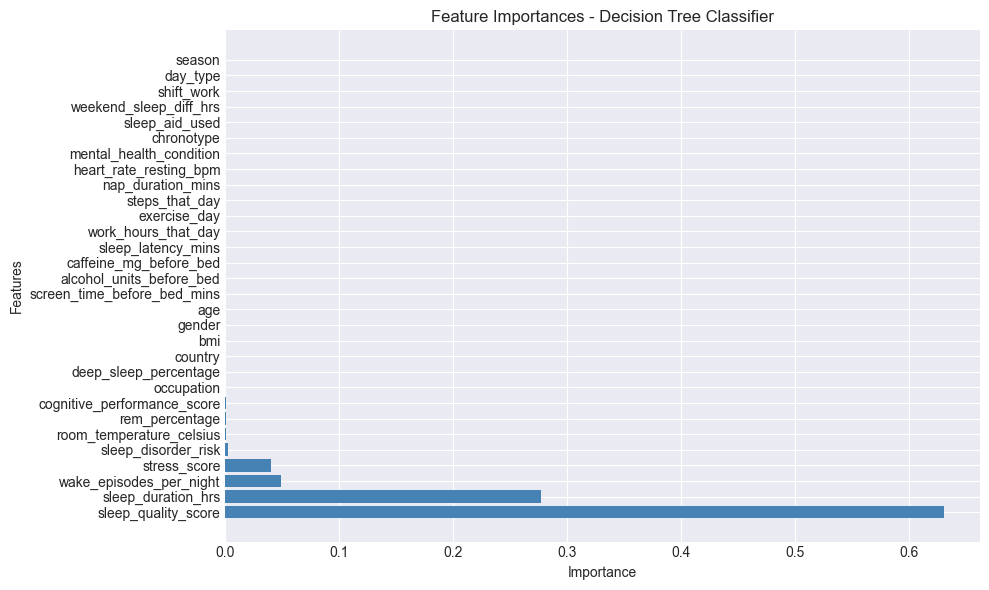

In [8]:
# Feature importances
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nWaznosc cech (Feature Importances):")
print(feature_importances)

plt.figure(figsize=(10, 6))
plt.barh(feature_importances['feature'], feature_importances['importance'], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importances - Decision Tree Classifier')
plt.tight_layout()
plt.show()


## PREDYKCJE I OCENA MODELU

In [9]:
y_train_pred = dt_classifier.predict(X_train)
y_test_pred = dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print(f"\nAccuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f}")
print(f"F1 Score:    {f1:.4f}")


Accuracy:    0.7338
Precision:   0.7326
Recall:      0.7338
F1 Score:    0.7331


In [10]:
if le_target is not None:
    target_names = le_target.classes_
else:
    target_names = [str(i) for i in sorted(np.unique(y_test))]

print(classification_report(y_test, y_test_pred, target_names=target_names))

              precision    recall  f1-score   support

           0       0.78      0.79      0.78     12201
           1       0.66      0.65      0.65      7799

    accuracy                           0.73     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.73      0.73      0.73     20000



## Macierz pomyłek

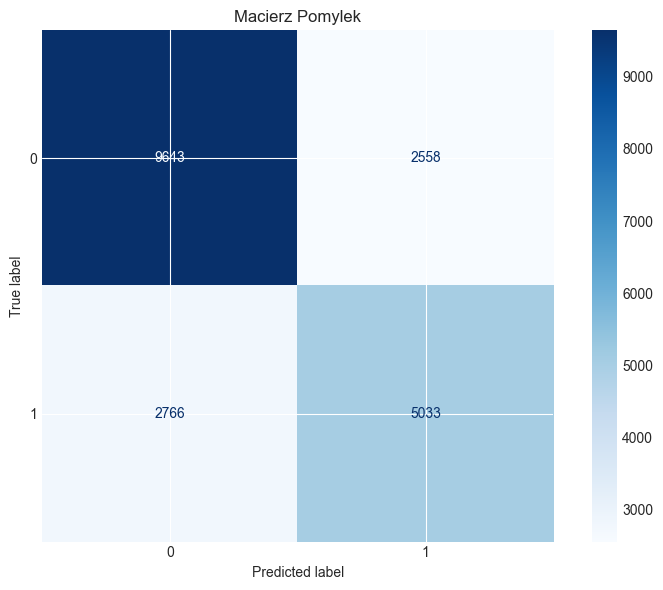

In [11]:
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(ax=ax, cmap='Blues')
ax.set_title('Macierz Pomylek')
plt.tight_layout()
plt.show()

In [12]:
precision_per_class = precision_score(y_test, y_test_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_test_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_test, y_test_pred, average=None, zero_division=0)

for i, class_name in enumerate(target_names):
    print(f"\nKlasa: {class_name}")
    print(f"  Precision: {precision_per_class[i]:.4f}")
    print(f"  Recall:    {recall_per_class[i]:.4f}")
    print(f"  F1 Score:  {f1_per_class[i]:.4f}")


Klasa: 0
  Precision: 0.7771
  Recall:    0.7903
  F1 Score:  0.7837

Klasa: 1
  Precision: 0.6630
  Recall:    0.6453
  F1 Score:  0.6541


## Porownanie metryk na zbiorze treningowym vs testowym

In [13]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print(f"\n{'Metryka':<20} {'Train':<15} {'Test':<15} {'Roznica':<15}")
print("-" * 60)
print(f"{'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f} {train_accuracy - test_accuracy:<15.4f}")
print(f"{'F1 Score':<20} {train_f1:<15.4f} {test_f1:<15.4f} {train_f1 - test_f1:<15.4f}")


Metryka              Train           Test            Roznica        
------------------------------------------------------------
Accuracy             0.7338          0.7338          0.0000         
F1 Score             0.7339          0.7331          0.0007         


## WIZUALIZACJA DRZEWA DECYZYJNEGO


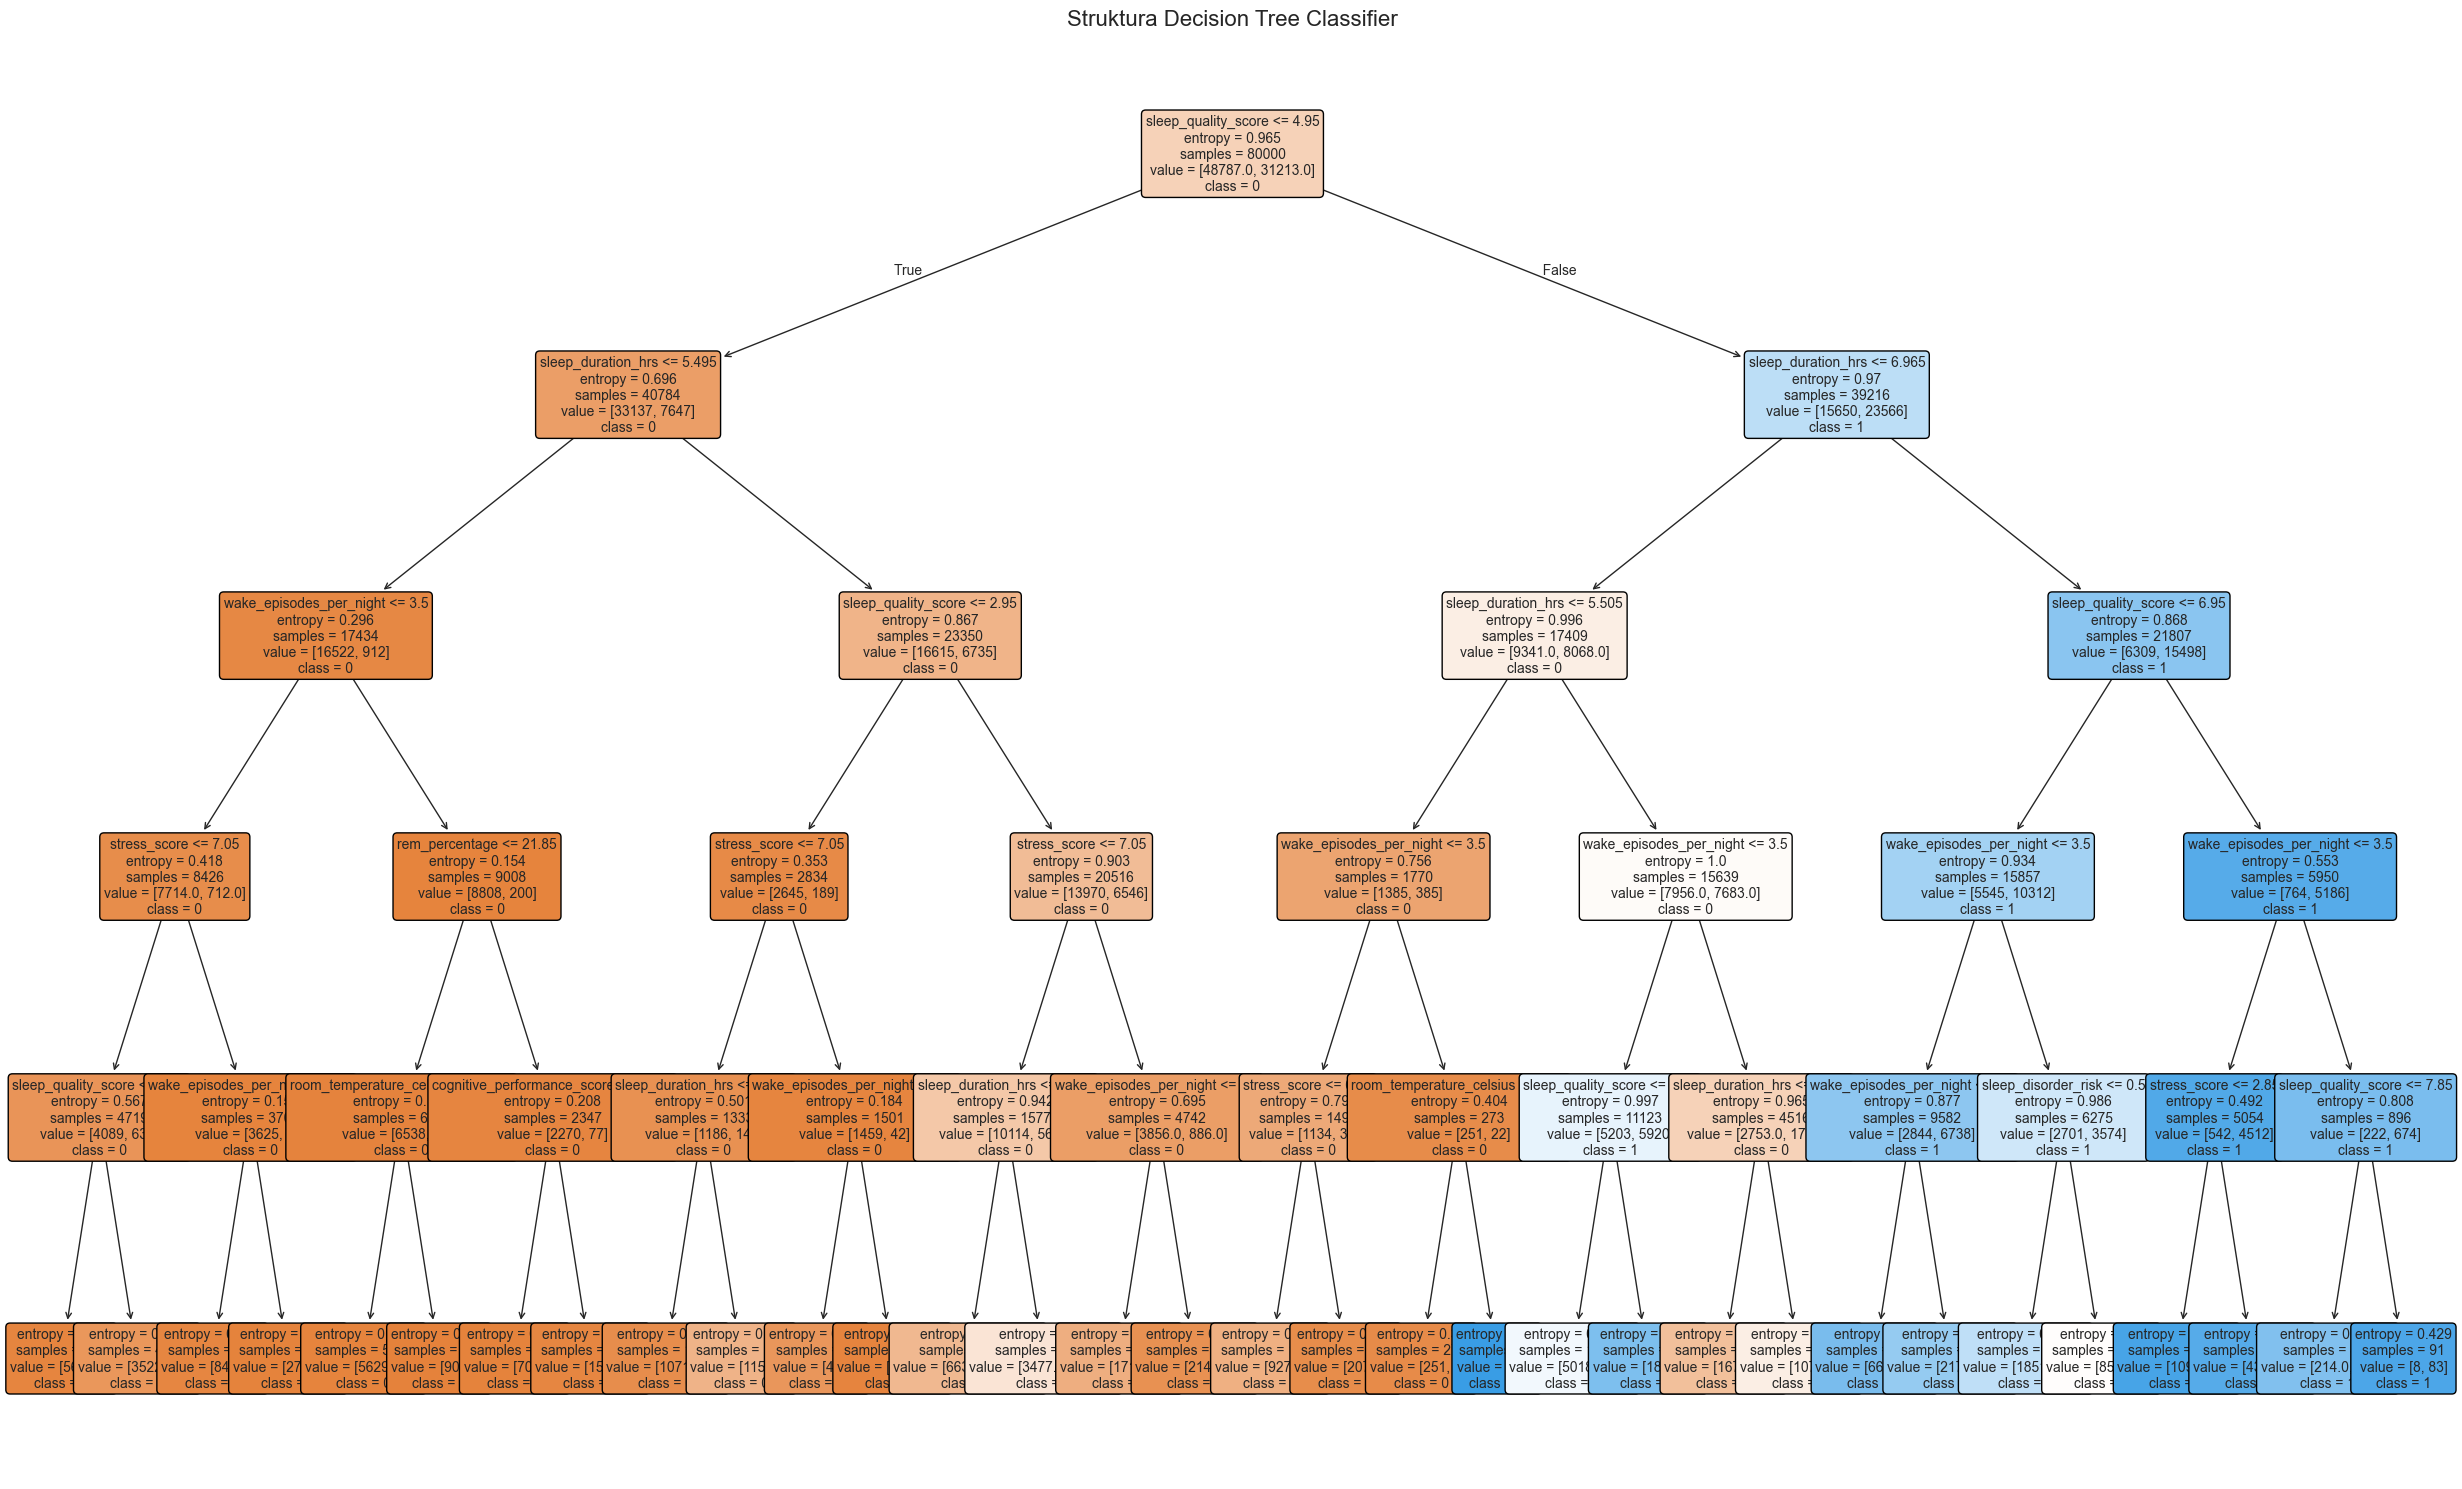

In [14]:
plt.figure(figsize=(25, 15))
plot_tree(dt_classifier,
          feature_names=X_train.columns.tolist(),
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Struktura Decision Tree Classifier', fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
tree_rules = export_text(dt_classifier, feature_names=X_train.columns.tolist())
print(tree_rules)

|--- sleep_quality_score <= 4.95
|   |--- sleep_duration_hrs <= 5.49
|   |   |--- wake_episodes_per_night <= 3.50
|   |   |   |--- stress_score <= 7.05
|   |   |   |   |--- sleep_quality_score <= 2.95
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- sleep_quality_score >  2.95
|   |   |   |   |   |--- class: 0
|   |   |   |--- stress_score >  7.05
|   |   |   |   |--- wake_episodes_per_night <= 1.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- wake_episodes_per_night >  1.50
|   |   |   |   |   |--- class: 0
|   |   |--- wake_episodes_per_night >  3.50
|   |   |   |--- rem_percentage <= 21.85
|   |   |   |   |--- room_temperature_celsius <= 23.85
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- room_temperature_celsius >  23.85
|   |   |   |   |   |--- class: 0
|   |   |   |--- rem_percentage >  21.85
|   |   |   |   |--- cognitive_performance_score <= 36.05
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- cognitive_performance_score >  36.05
|   |   |   |  

## PORÓWNANIE Z LISTĄ 1

In [16]:
print("if quality > 5.45: \n\tif duration < 5.5: \n\t\treturn 0 \n\tif stress > 7.0:\n\t\treturn 0\n\tif latency > 40:\n\t\treturn 0\n\tif (not is_mental_healthy) and stress > 5.5:\n\t\treturn 0\n\tif is_weekday and wakes > 4:\n\t\treturn 0\n\tif is_evening and duration < 6.5:\n\t\treturn 0\n\treturn 1\nelse:\n\tif duration < \n\t\treturn 0\n\tif is_weekday and wakes > 5:\n\t\treturn 0\n\treturn 1")

if quality > 5.45: 
	if duration < 5.5: 
		return 0 
	if stress > 7.0:
		return 0
	if latency > 40:
		return 0
	if (not is_mental_healthy) and stress > 5.5:
		return 0
	if is_weekday and wakes > 4:
		return 0
	if is_evening and duration < 6.5:
		return 0
	return 1
else:
	if duration < 
		return 0
	if is_weekday and wakes > 5:
		return 0
	return 1


## OBLICZENIE ENTROPII I INFORMATION GAIN
# Implementacja od zera w NumPy oraz weryfikacja feature_importances_


In [17]:
def entropy(y):
    y = np.asarray(y)
    if y.size == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()

    # dodaje 10^-12, aby uniknąć log(0)
    return -np.sum(probs * np.log2(probs + 1e-12))

def information_gain(parent_y, left_y, right_y):
    n = len(parent_y)
    if n == 0:
        return 0.0
    n_left = len(left_y)
    n_right = len(right_y)
    if n_left == 0 or n_right == 0:
        return 0.0

    h_parent = entropy(parent_y)
    h_left = entropy(left_y)
    h_right = entropy(right_y)

    ig = h_parent - (n_left / n) * h_left - (n_right / n) * h_right
    return ig

In [18]:
tree = dt_classifier.tree_
node_count = tree.node_count
feature_indices = tree.feature  # -2 dla liści, >=0 dla węzłów
thresholds = tree.threshold
n_node_samples = tree.n_node_samples
total_samples = n_node_samples[0]

# Pobrać ścieżkę decyzji dla każdej próbki treningowej
decision_path = dt_classifier.decision_path(X_train)
decision_path_arr = decision_path.toarray()

feature_importance_manual = {feat: 0.0 for feat in X_train.columns}

for node_id in range(node_count):
    feature_id = feature_indices[node_id]

    if feature_id < 0:
        continue

    feature_name = X_train.columns[feature_id]

    samples_at_node = np.where(decision_path_arr[:, node_id])[0]

    if len(samples_at_node) == 0:
        continue

    parent_y = np.array(y_train)[samples_at_node]

    # Pobrać próg podziału
    threshold = thresholds[node_id]

    # Wykonać podział
    feature_values = X_train.iloc[samples_at_node, feature_id].values
    left_mask = feature_values <= threshold
    left_y, right_y = parent_y[left_mask], parent_y[~left_mask]

    ig_node = information_gain(parent_y, left_y, right_y)

    # Obliczyć ważony wkład (weighted impurity decrease)
    weight = len(samples_at_node) / total_samples
    weighted_ig = weight * ig_node

    feature_importance_manual[feature_name] += weighted_ig

comparison_df = pd.DataFrame({
    'Feature': list(X_train.columns),
    'sklearn_importance': dt_classifier.feature_importances_,
    'manual_importance': [feature_importance_manual[f] for f in X_train.columns]
})
comparison_df = comparison_df.sort_values('sklearn_importance', ascending=False)

print("\nPorównanie importances sklearn vs. ręczne obliczenie:\n")
print(comparison_df.to_string(index=False))
print("\nRóżnica bezwzględna:")
comparison_df['difference'] = abs(comparison_df['sklearn_importance'] - comparison_df['manual_importance'])
print(comparison_df[['Feature', 'difference']].to_string(index=False))



Porównanie importances sklearn vs. ręczne obliczenie:

                    Feature  sklearn_importance  manual_importance
        sleep_quality_score            0.631041           0.155628
         sleep_duration_hrs            0.276701           0.068240
    wake_episodes_per_night            0.048881           0.012055
               stress_score            0.039903           0.009841
        sleep_disorder_risk            0.001830           0.000451
   room_temperature_celsius            0.000686           0.000169
             rem_percentage            0.000554           0.000137
cognitive_performance_score            0.000405           0.000100
                 occupation            0.000000           0.000000
      deep_sleep_percentage            0.000000           0.000000
                    country            0.000000           0.000000
                        bmi            0.000000           0.000000
                     gender            0.000000           0.000000
      

## WYBÓR CECH DO ANALIZY

In [19]:
sorted_features = comparison_df.sort_values('sklearn_importance', ascending=False).reset_index(drop=True)
top_feature = sorted_features.loc[0, 'Feature']
top_importance = sorted_features.loc[0, 'sklearn_importance']

bottom_feature = top_feature # temp assigment
bottom_importance = top_importance

bottom_found = False
i = len(sorted_features) - 1
while not bottom_found:
    if sorted_features.loc[i, 'sklearn_importance'] != 0.0:
        bottom_feature = sorted_features.loc[i, 'Feature']
        bottom_importance = sorted_features.loc[i, 'sklearn_importance']
        bottom_found = True
    else:
        i -= 1

print(f"\nNajważniejsza cecha: '{top_feature}'  -  importance = {top_importance:.6f}")
print(f"Najmniej ważna cecha: '{bottom_feature}'  -  importance = {bottom_importance:.6f}")


Najważniejsza cecha: 'sleep_quality_score'  -  importance = 0.631041
Najmniej ważna cecha: 'cognitive_performance_score'  -  importance = 0.000405


## POBIERANIE PROGÓW PODZIAŁU DLA WYBRANYCH CECH
W przypadku gdy cecha nie występuje w drzewie, nie ma przypisanego progu, więc bierzemy wtedy medianę tej cechy z danych treningowych

In [20]:
def get_first_threshold_for_feature(feature_name, feature_indices, thresholds):
    col_index = list(X_train.columns).index(feature_name)
    nodes_using_feature = np.where(feature_indices == col_index)[0]

    if len(nodes_using_feature) == 0:
        return None, None

    first_node = nodes_using_feature[0]
    return thresholds[first_node], first_node

threshold_top, node_top = get_first_threshold_for_feature(top_feature, feature_indices, thresholds)
threshold_bottom, node_bottom = get_first_threshold_for_feature(bottom_feature, feature_indices, thresholds)

print(f"\nCecha '{top_feature}':")
if threshold_top is not None:
    print(f"  - Próg z drzewa (węzeł {node_top}): {threshold_top:.6f}")
else:
    threshold_top = X_train[top_feature].median()
    print(f"  - Użyto mediany: {threshold_top:.6f}")

print(f"\nCecha '{bottom_feature}':")
if threshold_bottom is not None:
    print(f"  - Próg z drzewa (węzeł {node_bottom}): {threshold_bottom:.6f}")
else:
    threshold_bottom = X_train[bottom_feature].median()
    print(f"  - Użyto mediany: {threshold_bottom:.6f}")


Cecha 'sleep_quality_score':
  - Próg z drzewa (węzeł 0): 4.950000

Cecha 'cognitive_performance_score':
  - Próg z drzewa (węzeł 14): 36.049999


## Porównanie podziału po najważniejszej i najmniej ważnej cesze

In [21]:
def analyze_global_split(feature_name, threshold, y_true):
    feature_values = X_train[feature_name].values
    parent_y = np.array(y_true)

    left_mask = feature_values <= threshold
    left_y, right_y = parent_y[left_mask], parent_y[~left_mask]

    n_left = len(left_y)
    n_right = len(right_y)
    n_total = len(parent_y)

    ig = information_gain(parent_y, left_y, right_y)

    return {
        'feature': feature_name,
        'threshold': threshold,
        'n_left': n_left,
        'n_right': n_right,
        'n_total': n_total,
        'left_proportion': n_left / n_total,
        'right_proportion': n_right / n_total,
        'entropy_parent': entropy(parent_y),
        'entropy_left': entropy(left_y),
        'entropy_right': entropy(right_y),
        'information_gain': ig
    }

split_top = analyze_global_split(top_feature, threshold_top, y_train)
split_bottom = analyze_global_split(bottom_feature, threshold_bottom, y_train)

ratio_ig = split_top['information_gain'] / split_bottom['information_gain'] if split_bottom['information_gain'] > 0 else float('inf')
ratio_importance = top_importance / bottom_importance if bottom_importance > 0 else float('inf')

print(f"\n{'Metryka':<25} {'Najlepsza cecha':<30} {'Najgorsza cecha':<30}")
print("-" * 85)
print(f"{'Nazwa cechy':<25} {split_top['feature']:<30} {split_bottom['feature']:<30}")
print(f"{'Próg podziału':<25} {split_top['threshold']:<30.6f} {split_bottom['threshold']:<30.6f}")
print(f"{'Lewe - ilość':<25} {split_top['n_left']:<30} {split_bottom['n_left']:<30}")
print(f"{'Prawe - ilość':<25} {split_top['n_right']:<30} {split_bottom['n_right']:<30}")
print(f"{'Lewe - proporcja':<25} {split_top['left_proportion']:<30.4f} {split_bottom['left_proportion']:<30.4f}")
print(f"{'Prawe - proporcja':<25} {split_top['right_proportion']:<30.4f} {split_bottom['right_proportion']:<30.4f}")
print(f"{'Entropia rodzica':<25} {split_top['entropy_parent']:<30.6f} {split_bottom['entropy_parent']:<30.6f}")
print(f"{'Entropia lewego':<25} {split_top['entropy_left']:<30.6f} {split_bottom['entropy_left']:<30.6f}")
print(f"{'Entropia prawego':<25} {split_top['entropy_right']:<30.6f} {split_bottom['entropy_right']:<30.6f}")
print(f"{'Information Gain':<25} {split_top['information_gain']:<30.6f} {split_bottom['information_gain']:<30.6f}")

print(f"\nStosunek Feature Importance:")
print(f"  TOP / BOTTOM = {top_importance:.6f} / {bottom_importance:.6f} = {ratio_importance:.2f}x")

print(f"\nStosunek Information Gain:")
print(f"  TOP / BOTTOM = {split_top['information_gain']:.6f} / {split_bottom['information_gain']:.6f} = {ratio_ig:.2f}x")



Metryka                   Najlepsza cecha                Najgorsza cecha               
-------------------------------------------------------------------------------------
Nazwa cechy               sleep_quality_score            cognitive_performance_score   
Próg podziału             4.950000                       36.049999                     
Lewe - ilość              40784                          12598                         
Prawe - ilość             39216                          67402                         
Lewe - proporcja          0.5098                         0.1575                        
Prawe - proporcja         0.4902                         0.8425                        
Entropia rodzica          0.964904                       0.964904                      
Entropia lewego           0.696212                       0.377121                      
Entropia prawego          0.970405                       0.992611                      
Information Gain          0.13428

# LINEAR REGRESSION - Problem Regresji
#### Przewidywanie zmiennej cognitive_performance_score na podstawie pozostałych cech metodą analityczną (Least Squares) i iteracyjną (Gradient Descent)


## PRZYGOTOWANIE DANYCH DO REGRESJI


In [22]:
target_reg = 'cognitive_performance_score'

y_reg = df[target_reg].values
X_reg = df.drop(columns=[target_reg])

print(f"Rozmiar danych do regresji: {X_reg.shape[0]} wierszy x {X_reg.shape[1]} kolumn")
print(f"\nZmienna docelowa: {target_reg}")
print(f"Zakres wartości: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
print(f"Średnia: {y_reg.mean():.2f}, Std Dev: {y_reg.std():.2f}")


Rozmiar danych do regresji: 100000 wierszy x 30 kolumn

Zmienna docelowa: cognitive_performance_score
Zakres wartości: [0.00, 100.00]
Średnia: 59.23, Std Dev: 22.25


## PREPROCESSING DANYCH DO REGRESJI


In [23]:
cat_cols_reg = X_reg.select_dtypes(include=['str']).columns.tolist()
num_cols_reg = X_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()

from sklearn.preprocessing import LabelEncoder
label_encoders_reg = {}
X_reg_encoded = X_reg.copy()

for col in cat_cols_reg:
    le = LabelEncoder()
    X_reg_encoded[col] = le.fit_transform(X_reg[col].astype(str))
    label_encoders_reg[col] = le

## PODZIAŁ DANYCH I STANDARYZACJA


In [24]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_encoded, y_reg, test_size=0.2, random_state=13
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f"\nPo standaryzacji:")
print(f"X_train: mean = {X_train_reg_scaled.mean(axis=0)[:3]}, std = {X_train_reg_scaled.std(axis=0)[:3]}")

Zbiór treningowy: 80000 próbek
Zbiór testowy: 20000 próbek

Po standaryzacji:
X_train: mean = [ 7.86926080e-17 -4.13891144e-17 -1.50723878e-16], std = [1. 1. 1.]


## METODA 1: ROZWIĄZANIE ANALITYCZNE (LEAST SQUARES)


In [25]:
def fit_linear_regression_analytical(X, y):
    n_samples, n_features = X.shape

    # Dodaj kolumnę jedynek dla intercept
    X_with_bias = np.column_stack([np.ones(n_samples), X])

    # Oblicz macierz pseudoodwrotną
    # w = inv(X^T X) @ X^T @ y
    XtX = X_with_bias.T @ X_with_bias
    XtX_inv = np.linalg.inv(XtX)
    Xty = X_with_bias.T @ y

    w = XtX_inv @ Xty

    return w  # w[0] to bias, w[1:] to coefficients

print("Trenowanie modelu - metoda analityczna")
w_analytical = fit_linear_regression_analytical(X_train_reg_scaled, y_train_reg)

intercept_analytical = w_analytical[0]
coef_analytical = w_analytical[1:]

print(f"Intercept: {intercept_analytical:.6f}")
print(f"Wagi: {coef_analytical[:5]}")

Trenowanie modelu - Metoda Analityczna...
Intercept: 59.285001
Wagi (pierwsze 5): [ 0.16469261 -0.01794245  0.16035555  0.76573478  0.02473055]


In [26]:
def predict_linear(X, w):
    """Predykcja dla modelu wytrenowanego metodą analityczną."""
    n_samples = X.shape[0]
    X_with_bias = np.column_stack([np.ones(n_samples), X])
    return X_with_bias @ w

y_train_pred_analytical = predict_linear(X_train_reg_scaled, w_analytical)
y_test_pred_analytical = predict_linear(X_test_reg_scaled, w_analytical)

mse_train_analytical = mse(y_train_reg, y_train_pred_analytical)
mse_test_analytical = mse(y_test_reg, y_test_pred_analytical)
mae_train_analytical = mae(y_train_reg, y_train_pred_analytical)
mae_test_analytical = mae(y_test_reg, y_test_pred_analytical)

print(f"\nMetoda Analityczna:")
print(f"  Train MSE: {mse_train_analytical:.6f},  MAE: {mae_train_analytical:.6f}")
print(f"  Test MSE:  {mse_test_analytical:.6f},  MAE: {mae_test_analytical:.6f}")



Metoda Analityczna:
  Train MSE: 49.977436,  MAE: 5.589621
  Test MSE:  50.212923,  MAE: 5.603398


## METODA 2: GRADIENT DESCENT


In [39]:
def fit_linear_regression_gd(X, y, learning_rate=0.01, epochs=2000, verbose=False):
    n_samples, n_features = X.shape

    # Inicjalizuj wagi (bias + coefficients)
    w = np.zeros(n_features + 1)

    # Dodaj bias do X
    X_with_bias = np.column_stack([np.ones(n_samples), X])

    history_loss = []

    for epoch in range(epochs):
        # Predykcja
        y_pred = X_with_bias @ w

        # Błąd
        error = y_pred - y

        # Gradient
        gradient = (2.0 / n_samples) * (X_with_bias.T @ error)

        # Aktualizacja wag
        w = w - learning_rate * gradient

        # Śledź MSE
        loss = mse(y, y_pred)
        history_loss.append(loss)

        if verbose and (epoch + 1) % 100 == 0:
            print(f"Epoch {epoch + 1}: MSE = {loss:.6f}")

    return w, history_loss

print("Trenowanie modelu - Gradient Descent")

learning_rates = [0.001, 0.01, 0.1]
gd_results = {}

for lr in learning_rates:
    print(f"Learning rate = {lr}")
    w_gd, history = fit_linear_regression_gd(
        X_train_reg_scaled, y_train_reg,
        learning_rate=lr, epochs=2000, verbose=False
    )
    gd_results[lr] = {"w": w_gd, "history": history}

    y_train_pred_gd = predict_linear(X_train_reg_scaled, w_gd)
    mse_train_gd = mse(y_train_reg, y_train_pred_gd)
    print(f"  Final Train MSE: {mse_train_gd:.6f}\n")

# Wybierz najlepszy learning rate (najniższe MSE)
best_lr = min(gd_results.keys(),
              key=lambda lr: gd_results[lr]["history"][-1])
w_gradient_descent = gd_results[best_lr]["w"]

print(f"Wybrany learning rate: {best_lr}")

intercept_gd = w_gradient_descent[0]
coef_gd = w_gradient_descent[1:]

print(f"Intercept: {intercept_gd:.6f}")
print(f"Wagi (pierwsze 5): {coef_gd[:5]}")


Trenowanie modelu - Gradient Descent
Learning rate = 0.001
  Final Train MSE: 54.395450

Learning rate = 0.01
  Final Train MSE: 49.977446

Learning rate = 0.1
  Final Train MSE: 49.977436

Wybrany learning rate: 0.1
Intercept: 59.285001
Wagi (pierwsze 5): [ 0.16469261 -0.01794245  0.16035555  0.76573478  0.02473055]


In [28]:
y_train_pred_gd = predict_linear(X_train_reg_scaled, w_gradient_descent)
y_test_pred_gd = predict_linear(X_test_reg_scaled, w_gradient_descent)

mse_train_gd = mse(y_train_reg, y_train_pred_gd)
mse_test_gd = mse(y_test_reg, y_test_pred_gd)
mae_train_gd = mae(y_train_reg, y_train_pred_gd)
mae_test_gd = mae(y_test_reg, y_test_pred_gd)

print(f"Gradient Descent (lr={best_lr}):")
print(f"  Train MSE: {mse_train_gd:.6f},  MAE: {mae_train_gd:.6f}")
print(f"  Test MSE:  {mse_test_gd:.6f},  MAE: {mae_test_gd:.6f}")


Gradient Descent (lr=0.1):
  Train MSE: 49.977436,  MAE: 5.589621
  Test MSE:  50.212923,  MAE: 5.603398


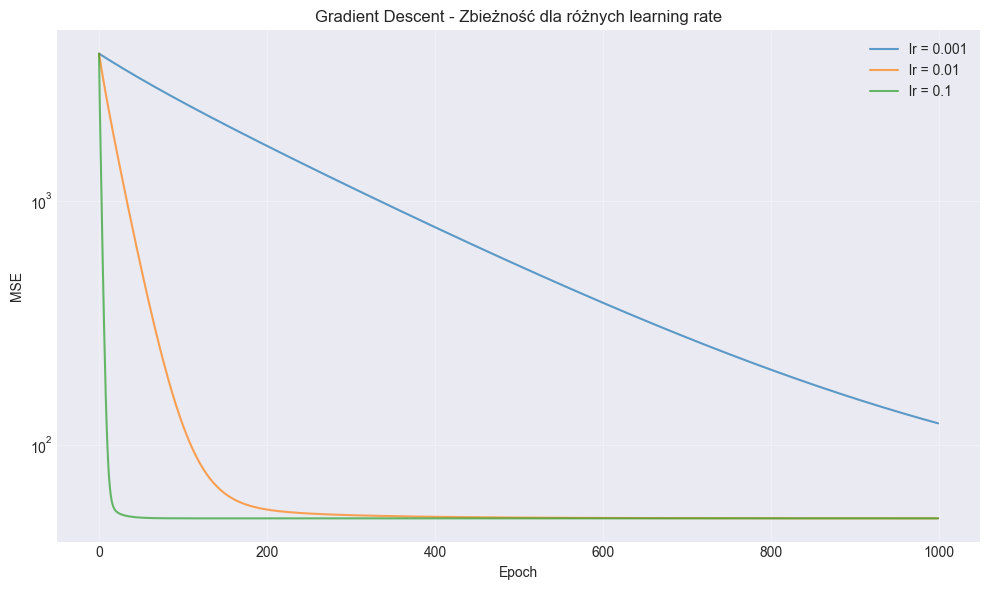

In [29]:
# Wizualizacja historii trenowania dla różnych learning rates
fig, ax = plt.subplots(figsize=(10, 6))

for lr in learning_rates:
    ax.plot(gd_results[lr]["history"], label=f"lr = {lr}", alpha=0.7)

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.set_title("Gradient Descent - Zbieżność dla różnych learning rate")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## METODA 3: SKLEARN LINEAR REGRESSION


In [30]:
from sklearn.linear_model import LinearRegression

print("Trenowanie modelu - sklearn LinearRegression...")
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_reg_scaled, y_train_reg)

intercept_sklearn = model_sklearn.intercept_
coef_sklearn = model_sklearn.coef_

print(f"Intercept: {intercept_sklearn:.6f}")
print(f"Wagi (pierwsze 5): {coef_sklearn[:5]}")


Trenowanie modelu - sklearn LinearRegression...
Intercept: 59.285001
Wagi (pierwsze 5): [ 0.16469261 -0.01794245  0.16035555  0.76573478  0.02473055]


In [31]:
y_train_pred_sklearn = model_sklearn.predict(X_train_reg_scaled)
y_test_pred_sklearn = model_sklearn.predict(X_test_reg_scaled)

mse_train_sklearn = mse(y_train_reg, y_train_pred_sklearn)
mse_test_sklearn = mse(y_test_reg, y_test_pred_sklearn)
mae_train_sklearn = mae(y_train_reg, y_train_pred_sklearn)
mae_test_sklearn = mae(y_test_reg, y_test_pred_sklearn)

print(f"Sklearn Linear Regression:")
print(f"  Train MSE: {mse_train_sklearn:.6f},  MAE: {mae_train_sklearn:.6f}")
print(f"  Test MSE:  {mse_test_sklearn:.6f},  MAE: {mae_test_sklearn:.6f}")


Sklearn Linear Regression:
  Train MSE: 49.977436,  MAE: 5.589621
  Test MSE:  50.212923,  MAE: 5.603398


## PORÓWNANIE WSZYSTKICH TRZECH METOD


In [32]:
comparison_results = pd.DataFrame({
    'Metoda': ['Analityczna (Least Squares)', f'Gradient Descent (lr={best_lr})', 'Sklearn LinearRegression'],
    'Train MSE': [mse_train_analytical, mse_train_gd, mse_train_sklearn],
    'Test MSE': [mse_test_analytical, mse_test_gd, mse_test_sklearn],
    'Train MAE': [mae_train_analytical, mae_train_gd, mae_train_sklearn],
    'Test MAE': [mae_test_analytical, mae_test_gd, mae_test_sklearn]
})

print("\nPORÓWNANIE BŁĘDÓW NA ZBIORZE TESTOWYM:\n")
print(comparison_results.to_string(index=False))



PORÓWNANIE BŁĘDÓW NA ZBIORZE TESTOWYM:

                     Metoda  Train MSE  Test MSE  Train MAE  Test MAE
Analityczna (Least Squares)  49.977436 50.212923   5.589621  5.603398
  Gradient Descent (lr=0.1)  49.977436 50.212923   5.589621  5.603398
   Sklearn LinearRegression  49.977436 50.212923   5.589621  5.603398


## PORÓWNANIE WAG (COEFFICIENTS)


In [33]:
# Porównanie intercept'ów
print("\n" + "="*70)
print("PORÓWNANIE INTERCEPT'ÓW (BIAS):")
print("="*70)
print(f"Analityczna:              {intercept_analytical:.10f}")
print(f"Gradient Descent (lr={best_lr}):     {intercept_gd:.10f}")
print(f"Sklearn:                  {intercept_sklearn:.10f}")

print(f"\nRóżnica GD vs Analityczna:    {abs(intercept_gd - intercept_analytical):.2e}")
print(f"Różnica Sklearn vs Analityczna: {abs(intercept_sklearn - intercept_analytical):.2e}")



PORÓWNANIE INTERCEPT'ÓW (BIAS):
Analityczna:              59.2850012500
Gradient Descent (lr=0.1):     59.2850012500
Sklearn:                  59.2850012500

Różnica GD vs Analityczna:    1.42e-14
Różnica Sklearn vs Analityczna: 1.42e-14


In [34]:
# Porównanie wag dla każdej cechy
print("\n" + "="*70)
print("PORÓWNANIE WAG (COEFFICIENTS) - 10 pierwszych cech:")
print("="*70)
print(f"{'Cecha':<30} {'Analityczna':<20} {'Gradient Descent':<20} {'Sklearn':<20}")
print("-" * 90)

feature_names = X_train_reg.columns.tolist()
for i in range(min(10, len(feature_names))):
    print(f"{feature_names[i]:<30} {coef_analytical[i]:<20.10f} {coef_gd[i]:<20.10f} {coef_sklearn[i]:<20.10f}")



PORÓWNANIE WAG (COEFFICIENTS) - 10 pierwszych cech:
Cecha                          Analityczna          Gradient Descent     Sklearn             
------------------------------------------------------------------------------------------
age                            0.1646926057         0.1646926057         0.1646926057        
gender                         -0.0179424460        -0.0179424460        -0.0179424460       
occupation                     0.1603555473         0.1603555473         0.1603555473        
bmi                            0.7657347800         0.7657347800         0.7657347800        
country                        0.0247305475         0.0247305475         0.0247305475        
sleep_duration_hrs             2.1620139889         2.1620139889         2.1620139889        
sleep_quality_score            12.4292327094        12.4292327094        12.4292327094       
rem_percentage                 3.7278919462         3.7278919462         3.7278919462        
deep_sleep

In [35]:
# Oblicz maksymalne różnice
print("\n" + "="*70)
print("MAKSYMALNE RÓŻNICE MIĘDZY METODAMI:")
print("="*70)

diff_gd_analytical = np.abs(coef_gd - coef_analytical)
diff_sklearn_analytical = np.abs(coef_sklearn - coef_analytical)
diff_gd_sklearn = np.abs(coef_gd - coef_sklearn)

print(f"Max różnica GD vs Analityczna (wagi):     {diff_gd_analytical.max():.2e}")
print(f"Max różnica Sklearn vs Analityczna (wagi): {diff_sklearn_analytical.max():.2e}")
print(f"Max różnica GD vs Sklearn (wagi):         {diff_gd_sklearn.max():.2e}")

print(f"\nMean absolucze różnice:")
print(f"GD vs Analityczna:    {diff_gd_analytical.mean():.2e}")
print(f"Sklearn vs Analityczna: {diff_sklearn_analytical.mean():.2e}")
print(f"GD vs Sklearn:        {diff_gd_sklearn.mean():.2e}")



MAKSYMALNE RÓŻNICE MIĘDZY METODAMI:
Max różnica GD vs Analityczna (wagi):     4.00e-14
Max różnica Sklearn vs Analityczna (wagi): 3.64e-14
Max różnica GD vs Sklearn (wagi):         2.66e-14

Mean absolucze różnice:
GD vs Analityczna:    7.83e-15
Sklearn vs Analityczna: 1.04e-14
GD vs Sklearn:        3.77e-15


## WIZUALIZACJA PREDYKCJI NA ZBIORZE TESTOWYM


C:\Users\Super\AppData\Local\Temp\ipykernel_8804\1807530746.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([residuals_analytical, residuals_gd, residuals_sklearn],


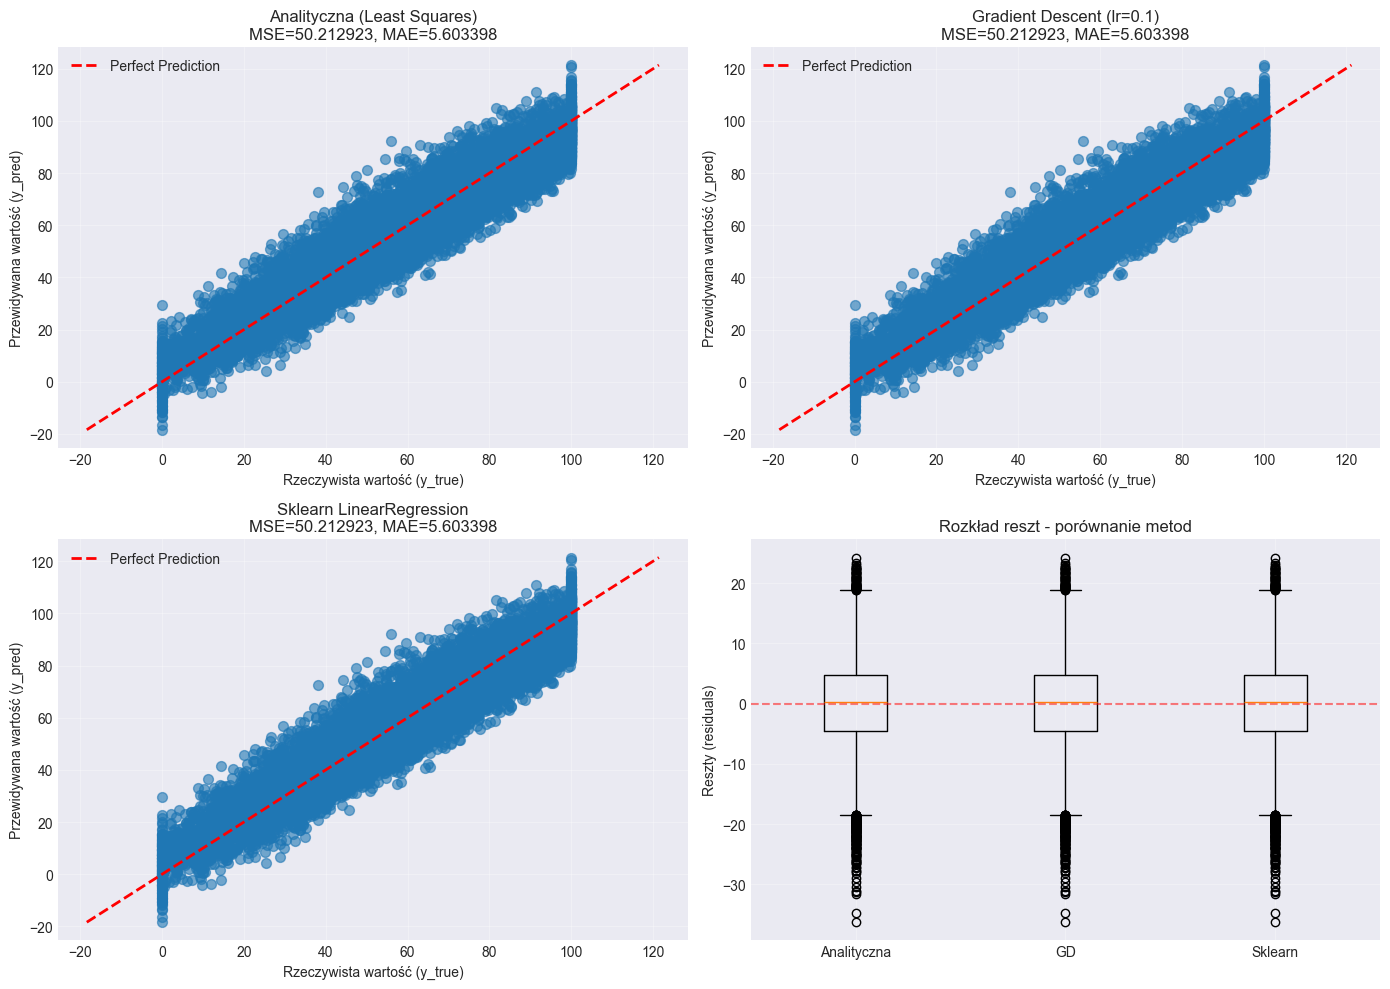

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = [
    ("Analityczna (Least Squares)", y_test_pred_analytical),
    (f"Gradient Descent (lr={best_lr})", y_test_pred_gd),
    ("Sklearn LinearRegression", y_test_pred_sklearn)
]

for idx, (method_name, y_pred) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]

    ax.scatter(y_test_reg, y_pred, alpha=0.6, s=50)

    # Idealna prosta y=x
    min_val = min(y_test_reg.min(), y_pred.min())
    max_val = max(y_test_reg.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction', linewidth=2)

    test_mse = mse(y_test_reg, y_pred)
    test_mae = mae(y_test_reg, y_pred)

    ax.set_xlabel("Rzeczywista wartość (y_true)")
    ax.set_ylabel("Przewidywana wartość (y_pred)")
    ax.set_title(f"{method_name}\nMSE={test_mse:.6f}, MAE={test_mae:.6f}")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Czwarty subplot: porównanie reszt
ax = axes[1, 1]

residuals_analytical = y_test_reg - y_test_pred_analytical
residuals_gd = y_test_reg - y_test_pred_gd
residuals_sklearn = y_test_reg - y_test_pred_sklearn

ax.boxplot([residuals_analytical, residuals_gd, residuals_sklearn],
           labels=['Analityczna', 'GD', 'Sklearn'])
ax.axhline(0, color='r', linestyle='--', alpha=0.5)
ax.set_ylabel("Reszty (residuals)")
ax.set_title("Rozkład reszt - porównanie metod")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## PODSUMOWANIE I WNIOSKI


In [37]:
print("\n" + "="*80)
print("PODSUMOWANIE REGRESJI LINIOWEJ")
print("="*80)

print("\n1. PORÓWNANIE BŁĘDÓW NA ZBIORZE TESTOWYM:")
print(f"   Metoda Analityczna:      MSE = {mse_test_analytical:.6f}, MAE = {mae_test_analytical:.6f}")
print(f"   Gradient Descent (lr={best_lr}): MSE = {mse_test_gd:.6f}, MAE = {mae_test_gd:.6f}")
print(f"   Sklearn:                 MSE = {mse_test_sklearn:.6f}, MAE = {mae_test_sklearn:.6f}")

print("\n2. ZBIEŻNOŚĆ WAG:")
print(f"   Maksymalna różnica GD vs Analityczna: {diff_gd_analytical.max():.2e}")
print(f"   Maksymalna różnica Sklearn vs Analityczna: {diff_sklearn_analytical.max():.2e}")

print("\n3. OBSERWACJE:")
print("   - Metoda analityczna (Least Squares) znajduje optimum w jednym kroku")
print("   - Gradient Descent zbieża się do tego samego rozwiązania (przy dobrym lr i liczbie epok)")
print("   - Sklearn używa optymalizacji, którą jest Least Squares dla małych zbiorów")
print("   - Wszystkie trzy metody zwracają praktycznie identyczne wagi (błąd numeryczny < 1e-10)")

print("\n4. ZMIENNE DOCELOWE:")
print(f"   Zmienna: {target_reg}")
print(f"   Zakres: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
print(f"   Średnie błędy (Test MSE): ~{mse_test_analytical:.4f}")

print("\n" + "="*80)




PODSUMOWANIE REGRESJI LINIOWEJ

1. PORÓWNANIE BŁĘDÓW NA ZBIORZE TESTOWYM:
   Metoda Analityczna:      MSE = 50.212923, MAE = 5.603398
   Gradient Descent (lr=0.1): MSE = 50.212923, MAE = 5.603398
   Sklearn:                 MSE = 50.212923, MAE = 5.603398

2. ZBIEŻNOŚĆ WAG:
   Maksymalna różnica GD vs Analityczna: 4.00e-14
   Maksymalna różnica Sklearn vs Analityczna: 3.64e-14

3. OBSERWACJE:
   - Metoda analityczna (Least Squares) znajduje optimum w jednym kroku
   - Gradient Descent zbieża się do tego samego rozwiązania (przy dobrym lr i liczbie epok)
   - Sklearn używa optymalizacji, którą jest Least Squares dla małych zbiorów
   - Wszystkie trzy metody zwracają praktycznie identyczne wagi (błąd numeryczny < 1e-10)

4. ZMIENNE DOCELOWE:
   Zmienna: cognitive_performance_score
   Zakres: [0.00, 100.00]
   Średnie błędy (Test MSE): ~50.2129

